# AqSolDB — Representation Comparison at Scale

**Motivation**: our ESOL experiments (`Morgan_fingerprints.ipynb`) showed that
under scaffold-aware CV, RDKit descriptors dramatically beat Morgan
fingerprints (Test RMSE 0.89 vs 1.69) on 902 training molecules. We hypothesized
this is a *small-data effect*: Morgan bits need many training triggers to
become useful, and novel test scaffolds look more foreign when the training set
is small.

**This notebook tests that hypothesis** by running the same three-way
representation comparison on **AqSolDB (9,982 molecules — roughly 9× ESOL)**.

**Fixed across all experiments** (same as before):
- Same XGBoost, same hyperparameter grid
- Same `GroupKFold(n_splits=5)` scaffold-aware CV
- Same `random_state=42`, same `n_jobs=1`
- Same scaffold-split logic (largest-scaffold-first, 80/20)

**Only two things change vs `Morgan_fingerprints.ipynb`**:
- Dataset: AqSolDB instead of ESOL
- Target column name: `Solubility` (AqSolDB) instead of the ESOL column

**Prediction**: Morgan-only should improve dramatically. The ranking may flip —
Morgan may match or beat RDKit descriptors. Combined should now genuinely
help. If we see all three, that confirms the small-data hypothesis.

**Reference paper**: Sorkun, M. C., Khetan, A. & Er, S. *"AqSolDB, a curated
reference set of aqueous solubility and 2D descriptors for a diverse set of
compounds."* Sci. Data **6**, 143 (2019).
DOI: [10.1038/s41597-019-0151-1](https://doi.org/10.1038/s41597-019-0151-1)

## 1. Imports and constants

Identical to `Morgan_fingerprints.ipynb`.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from xgboost import XGBRegressor

RANDOM_STATE = 42
RADIUS = 2
N_BITS = 2048

# --- Skip flags: flip to True to run those experiments ---
RUN_MORGAN = True
RUN_COMBINED = False

os.makedirs("figures", exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Load AqSolDB

AqSolDB is **tab-separated** despite the `.csv` extension. Target column is
`Solubility` (logS in mol/L). We only need SMILES and Solubility here — the
pre-computed features that ship with AqSolDB are ignored since we compute
our own to be pipeline-consistent with the ESOL work.

In [2]:
df = pd.read_csv("AqSolDB/aqsoldb.csv", sep="\t")

TARGET = "Solubility"
SMILES_COL = "SMILES"

# Keep only the two columns we need + reset index
df = df[[SMILES_COL, TARGET]].reset_index(drop=True)

print("Rows initially :", len(df))
print(df.head(3))

Rows initially : 9982
                                SMILES  Solubility
0  [Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C   -3.616127
1                 O=C1Nc2cccc3cccc1c23   -3.254767
2                      Clc1ccc(C=O)cc1   -2.177078


### Quick data quality check

Drop rows with unparseable SMILES or missing target. AqSolDB is curated, so
this should remove very few rows.

In [3]:
def is_valid_smiles(smi):
    if not isinstance(smi, str):
        return False
    mol = Chem.MolFromSmiles(smi.strip())
    return mol is not None

initial_n = len(df)
df = df.dropna(subset=[TARGET])
df = df[df[SMILES_COL].apply(is_valid_smiles)].reset_index(drop=True)

print("Dropped for invalid SMILES / NaN target:", initial_n - len(df))
print("Rows after cleaning                   :", len(df))
print("Target range :", round(df[TARGET].min(), 3), "to", round(df[TARGET].max(), 3))
print("Target mean/std:", round(df[TARGET].mean(), 3), "/", round(df[TARGET].std(), 3))

y = df[TARGET]

[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not r

[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not r

[14:32:20] WARNING: not removing hydrogen atom without neighbors
[14:32:20] WARNING: not removing hydrogen atom without neighbors


Dropped for invalid SMILES / NaN target: 2
Rows after cleaning                   : 9980
Target range : -13.172 to 2.138
Target mean/std: -2.89 / 2.368


## 3. Compute scaffolds and split

Same logic as `Morgan_fingerprints.ipynb`. This is where the biggest visible
difference vs ESOL will show up — AqSolDB has many more unique scaffolds
because it's a broader chemical dataset.

In [4]:
def get_scaffold(smiles):
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(
            smiles=smiles,
            includeChirality=False,
        )
    except Exception:
        return ""

df["scaffold"] = df[SMILES_COL].apply(get_scaffold)
print("Unique scaffolds in AqSolDB:", df["scaffold"].nunique())

[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors


[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not r

[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors


[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:21] WARNING: not removing hydrogen atom without neighbors
[14:32:22] WARNING: not removing hydrogen atom without neighbors


[14:32:22] WARNING: not removing hydrogen atom without neighbors
[14:32:22] WARNING: not removing hydrogen atom without neighbors


Unique scaffolds in AqSolDB: 1947


In [5]:
def scaffold_split_indices(df, test_frac=0.20):
    scaffold_groups = df.groupby("scaffold").indices
    groups_sorted = sorted(scaffold_groups.values(), key=len, reverse=True)

    n_train_target = int(round(len(df) * (1 - test_frac)))
    train_idx = []
    test_idx = []
    for group in groups_sorted:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        else:
            test_idx.extend(group)
    return np.array(train_idx), np.array(test_idx)

train_idx, test_idx = scaffold_split_indices(df, test_frac=0.20)

print("Train molecules:", len(train_idx))
print("Test  molecules:", len(test_idx))

train_scaffolds = set(df.iloc[train_idx]["scaffold"])
test_scaffolds  = set(df.iloc[test_idx]["scaffold"])
print("Scaffold overlap between train and test:", len(train_scaffolds & test_scaffolds))
print("Number of unique scaffolds in training:", len(train_scaffolds))

Train molecules: 7984
Test  molecules: 1996
Scaffold overlap between train and test: 0
Number of unique scaffolds in training: 297


In [6]:
y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

groups_train = df.iloc[train_idx]["scaffold"].values
groups_test  = df.iloc[test_idx]["scaffold"].values

print("y_train shape:", y_train.shape)
print("y_test  shape:", y_test.shape)

y_train shape: (7984,)
y_test  shape: (1996,)


## 4. Representation #1 — RDKit descriptors

Same computation pipeline as ESOL. Expected column count on AqSolDB may
differ slightly from 199 (some descriptors may fail on different molecule
subsets); we just print the actual count.

In [7]:
descriptor_names = [name for name, _ in Descriptors._descList]

def compute_rdkit_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        return {name: np.nan for name in descriptor_names}
    result = {}
    for name, func in Descriptors._descList:
        try:
            result[name] = func(mol)
        except Exception:
            result[name] = np.nan
    return result

print("Computing RDKit descriptors for", len(df), "molecules...")
t0 = time.time()
rdkit_records = [compute_rdkit_descriptors(smi) for smi in df[SMILES_COL]]
print(f"Descriptor computation: {time.time()-t0:.1f}s")

X_rdkit_all = pd.DataFrame(rdkit_records, index=df.index)

# Cleaning identical to Morgan_fingerprints.ipynb
X_rdkit_all = X_rdkit_all.replace([np.inf, -np.inf], np.nan)
X_rdkit_all = X_rdkit_all.dropna(axis=1, how="any")

stds = X_rdkit_all.std()
X_rdkit_all = X_rdkit_all.drop(columns=stds[stds == 0].index.tolist())

scale = X_rdkit_all.abs().mean().clip(lower=1e-9)
low_var_ratio = X_rdkit_all.std() / scale
X_rdkit_all = X_rdkit_all.drop(columns=low_var_ratio[low_var_ratio < 1e-8].index.tolist())

# Drop columns with extreme values that XGBoost's DMatrix cannot handle
# (e.g., RDKit's Ipc descriptor overflows to ~1e158 on large AqSolDB molecules)
XGB_SAFE_MAX = 1e10
max_abs = X_rdkit_all.abs().max()
extreme_cols = max_abs[max_abs > XGB_SAFE_MAX].index.tolist()
if extreme_cols:
    print(f"Dropping columns with max abs > {XGB_SAFE_MAX:g}: {extreme_cols}")
    X_rdkit_all = X_rdkit_all.drop(columns=extreme_cols)

print("Final RDKit descriptor matrix shape:", X_rdkit_all.shape)

Computing RDKit descriptors for 9980 molecules...


[14:32:24] WARNING: not removing hydrogen atom without neighbors
[14:32:24] WARNING: not removing hydrogen atom without neighbors


[14:32:25] WARNING: not removing hydrogen atom without neighbors
[14:32:25] WARNING: not removing hydrogen atom without neighbors
[14:32:25] WARNING: not removing hydrogen atom without neighbors
[14:32:25] WARNING: not removing hydrogen atom without neighbors


[14:32:26] WARNING: not removing hydrogen atom without neighbors
[14:32:26] WARNING: not removing hydrogen atom without neighbors


[14:32:26] WARNING: not removing hydrogen atom without neighbors
[14:32:26] WARNING: not removing hydrogen atom without neighbors


...

[14:32:57] WARNING: not removing hydrogen atom without neighbors
[14:32:57] WARNING: not removing hydrogen atom without neighbors


[14:33:00] WARNING: not removing hydrogen atom without neighbors
[14:33:00] WARNING: not removing hydrogen atom without neighbors
[14:33:00] WARNING: not removing hydrogen atom without neighbors
[14:33:00] WARNING: not removing hydrogen atom without neighbors


Descriptor computation: 58.5s


Dropping columns with max abs > 1e+10: ['Ipc']
Final RDKit descriptor matrix shape: (9980, 202)


/home/sg182/miniconda3/envs/ML/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


## 5. Representation #2 — Morgan fingerprints

Same generator, same radius=2, same 2048 bits.

In [8]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=RADIUS,
    fpSize=N_BITS,
)

print("Computing Morgan fingerprints for", len(df), "molecules...")
t0 = time.time()

morgan_fingerprints = []
for smiles in df[SMILES_COL]:
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        morgan_fingerprints.append(np.zeros(N_BITS, dtype=np.int8))
        continue
    fp = morgan_generator.GetFingerprint(mol)
    morgan_fingerprints.append(np.array(fp, dtype=np.int8))

print(f"Morgan generation: {time.time()-t0:.1f}s")

morgan_columns = [f"bit_{i}" for i in range(N_BITS)]
X_morgan_all = pd.DataFrame(
    morgan_fingerprints,
    columns=morgan_columns,
    index=df.index,
)

print("Morgan fingerprint matrix shape:", X_morgan_all.shape)
print("Active bits per molecule: min={} median={} max={}".format(
    X_morgan_all.sum(axis=1).min(),
    int(X_morgan_all.sum(axis=1).median()),
    X_morgan_all.sum(axis=1).max(),
))
print("Overall bit density:", round(X_morgan_all.values.mean(), 4))

Computing Morgan fingerprints for 9980 molecules...


[14:33:21] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors


[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors


[14:33:22] WARNING: not removing hydrogen atom without neighbors


[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:22] WARNING: not removing hydrogen atom without neighbors
[14:33:23] WARNING: not removing hydrogen atom without neighbors


...

[14:33:25] WARNING: not removing hydrogen atom without neighbors


[14:33:25] WARNING: not removing hydrogen atom without neighbors
[14:33:25] WARNING: not removing hydrogen atom without neighbors


[14:33:26] WARNING: not removing hydrogen atom without neighbors
[14:33:26] WARNING: not removing hydrogen atom without neighbors


Morgan generation: 7.2s


Morgan fingerprint matrix shape: (9980, 2048)
Active bits per molecule: min=1 median=24 max=105
Overall bit density: 0.0127


## 6. Representation #3 — RDKit + Morgan

In [9]:
X_combined_all = pd.concat([X_rdkit_all, X_morgan_all], axis=1)

print("RDKit shape    :", X_rdkit_all.shape)
print("Morgan shape   :", X_morgan_all.shape)
print("Combined shape :", X_combined_all.shape)
print("Combined has any NaN:", X_combined_all.isna().any().any())

RDKit shape    : (9980, 202)
Morgan shape   : (9980, 2048)
Combined shape : (9980, 2250)
Combined has any NaN: False


## 7. Apply the split to all three matrices

In [10]:
X_train_rdkit    = X_rdkit_all.iloc[train_idx]
X_test_rdkit     = X_rdkit_all.iloc[test_idx]

X_train_morgan   = X_morgan_all.iloc[train_idx]
X_test_morgan    = X_morgan_all.iloc[test_idx]

X_train_combined = X_combined_all.iloc[train_idx]
X_test_combined  = X_combined_all.iloc[test_idx]

print("Shapes after splitting:")
print("  RDKit    :", X_train_rdkit.shape,    X_test_rdkit.shape)
print("  Morgan   :", X_train_morgan.shape,   X_test_morgan.shape)
print("  Combined :", X_train_combined.shape, X_test_combined.shape)

Shapes after splitting:
  RDKit    : (7984, 202) (1996, 202)
  Morgan   : (7984, 2048) (1996, 2048)
  Combined : (7984, 2250) (1996, 2250)


## 8. Shared XGBoost + GridSearchCV setup

Identical grid to ESOL. Same `n_jobs=1` for reproducibility with the ESOL
benchmark.

In [11]:
group_kfold = GroupKFold(n_splits=5)

xgb_param_grid = {
    "n_estimators":     [100, 200, 500],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [2, 3, 4],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

print("Grid size:", np.prod([len(v) for v in xgb_param_grid.values()]), "combinations")
print("Total fits per experiment:", np.prod([len(v) for v in xgb_param_grid.values()]) * 5)

def evaluate_on_test(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{name} test  RMSE = {rmse:.4f}")
    print(f"{name} test  MAE  = {mae:.4f}")
    print(f"{name} test  R2   = {r2:.4f}")
    return {"name": name, "rmse": rmse, "mae": mae, "r2": r2, "y_pred": y_pred}

Grid size: 108 combinations
Total fits per experiment: 540


## 3b. Validate the scaffold split before running more models

Before spending compute on Morgan-only, sanity-check what the scaffold split
looks like. The AqSolDB scaffold distribution is very different from ESOL's
and we want to understand it — not silently trust it.

In [12]:
# Basic counts
print("Train molecules:", len(train_idx))
print("Test  molecules:", len(test_idx))
print()
print("Unique train scaffolds:", len(set(groups_train)))
print("Unique test  scaffolds:", len(set(groups_test)))

Train molecules: 7984
Test  molecules: 1996

Unique train scaffolds: 297
Unique test  scaffolds: 1650


### Why does test have so many more unique scaffolds than train?

Our splitter is **largest-scaffold-first**: it fills training with the biggest
scaffold groups until it hits the 80% target, then everything else spills into
test. So the top-heavy scaffolds all land in training, and test inherits the
long tail of small/singleton scaffolds.

The histograms below make this concrete.

In [13]:
train_scaffold_sizes = pd.Series(groups_train).value_counts()
test_scaffold_sizes  = pd.Series(groups_test).value_counts()

print("Top 10 scaffolds by molecule count — TRAIN:")
print(train_scaffold_sizes.head(10).to_string())
print()
print("Top 10 scaffolds by molecule count — TEST:")
print(test_scaffold_sizes.head(10).to_string())
print()
print("Fraction of TRAIN molecules covered by top 10 scaffolds:",
      round(train_scaffold_sizes.head(10).sum() / len(groups_train), 3))
print("Fraction of TEST  molecules covered by top 10 scaffolds:",
      round(test_scaffold_sizes.head(10).sum() / len(groups_test), 3))
print()
print("Singleton scaffolds in TRAIN:", (train_scaffold_sizes == 1).sum())
print("Singleton scaffolds in TEST :", (test_scaffold_sizes == 1).sum())

Top 10 scaffolds by molecule count — TRAIN:
                                2940
c1ccccc1                        1753
c1ccc(-c2ccccc2)cc1              219
c1ccc2ccccc2c1                   152
c1ccc(Oc2ccccc2)cc1              139
C1CCCCC1                         117
c1ccncc1                         102
c1ccc(Cc2ccccc2)cc1               73
c1ccc(N=Nc2ccccc2)cc1             61
O=C1C=C2CCC3C4CCCC4CCC3C2CC1      54

Top 10 scaffolds by molecule count — TEST:
O=c1cc[nH]c2ccccc12                      3
O=c1cc[nH]cn1                            3
O=c1ccc2ccccc2[nH]1                      3
O=c1cccc2n1CC1CNCC2C1                    3
O=c1ccn(-c2ccccc2)c2cc(N3CCNCC3)ccc12    3
O=c1ccn(C2CC2)c2cc(N3CC4CC3CN4)ccc12     3
O=c1ccnc[nH]1                            3
O=c1ccoc2cc3c(cc12)CCCC3                 3
O=c1cnc2c(=O)[nH]cnc2[nH]1               3
O=c1cnc2cncnc2[nH]1                      3

Fraction of TRAIN molecules covered by top 10 scaffolds: 0.703
Fraction of TEST  molecules covered by top 10 sc

### GroupKFold fold-by-fold summary

We also want to know what each of the 5 GroupKFold validation folds looks like
— because if one fold contains, say, 90% of training molecules while another
contains 3%, the CV mean is dominated by a single fold and less trustworthy.

In [14]:
fold_rows = []
for fold_i, (tr_idx, va_idx) in enumerate(group_kfold.split(
        np.zeros((len(train_idx), 1)),   # dummy X
        np.zeros(len(train_idx)),         # dummy y
        groups=groups_train)):
    fold_rows.append({
        "fold": fold_i,
        "n_train":  len(tr_idx),
        "n_val":    len(va_idx),
        "n_train_scaffolds": len(set(groups_train[tr_idx])),
        "n_val_scaffolds":   len(set(groups_train[va_idx])),
        "overlap": len(set(groups_train[tr_idx]) & set(groups_train[va_idx])),
    })

fold_summary = pd.DataFrame(fold_rows)
print(fold_summary.to_string(index=False))
print("\nAll folds should have overlap=0 (GroupKFold guarantee).")

 fold  n_train  n_val  n_train_scaffolds  n_val_scaffolds  overlap
    0     5044   2940                296                1        0
    1     6231   1753                296                1        0
    2     6886   1098                199               98        0
    3     6886   1098                198               99        0
    4     6889   1095                199               98        0

All folds should have overlap=0 (GroupKFold guarantee).


## 9. Experiment 1 — RDKit descriptors only

**Long run**: ~20 minutes with n_jobs=2 (GridSearchCV) on 9× more data.

In [15]:
xgb_rdkit = XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=1,
    tree_method="hist",
)

grid_rdkit = GridSearchCV(
    estimator=xgb_rdkit,
    param_grid=xgb_param_grid,
    cv=group_kfold,
    scoring="neg_root_mean_squared_error",
    return_train_score=True,
    n_jobs=1,   # n_jobs=2 caused XGBoost native crash — reverted
)

t_start = time.time()
grid_rdkit.fit(X_train_rdkit, y_train, groups=groups_train)
runtime_rdkit = time.time() - t_start

best_rdkit = grid_rdkit.best_estimator_
cv_rmse_rdkit = -grid_rdkit.best_score_

print("=== RDKit-only ===")
print("Best hyperparameters:", grid_rdkit.best_params_)
print(f"Best scaffold-aware CV RMSE: {cv_rmse_rdkit:.4f}")
print(f"Runtime: {runtime_rdkit:.1f} s")
print()

res_rdkit = evaluate_on_test("RDKit-only", best_rdkit, X_test_rdkit, y_test)
res_rdkit["cv_rmse"] = cv_rmse_rdkit
res_rdkit["runtime"] = runtime_rdkit
res_rdkit["n_feats"] = X_train_rdkit.shape[1]

=== RDKit-only ===
Best hyperparameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 1.0}
Best scaffold-aware CV RMSE: 1.1100
Runtime: 533.2 s

RDKit-only test  RMSE = 1.2665
RDKit-only test  MAE  = 0.9450
RDKit-only test  R2   = 0.6829


## 10. Experiment 2 — Morgan fingerprints only

**Long run**: ~1 hour with n_jobs=2 (GridSearchCV).

In [16]:
if RUN_MORGAN:
    xgb_morgan = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
    )
    
    grid_morgan = GridSearchCV(
        estimator=xgb_morgan,
        param_grid=xgb_param_grid,
        cv=group_kfold,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
        n_jobs=1,   # n_jobs=2 caused XGBoost native crash — reverted
    )
    
    t_start = time.time()
    grid_morgan.fit(X_train_morgan, y_train, groups=groups_train)
    runtime_morgan = time.time() - t_start
    
    best_morgan = grid_morgan.best_estimator_
    cv_rmse_morgan = -grid_morgan.best_score_
    
    print("=== Morgan-only ===")
    print("Best hyperparameters:", grid_morgan.best_params_)
    print(f"Best scaffold-aware CV RMSE: {cv_rmse_morgan:.4f}")
    print(f"Runtime: {runtime_morgan:.1f} s")
    print()
    
    res_morgan = evaluate_on_test("Morgan-only", best_morgan, X_test_morgan, y_test)
    res_morgan["cv_rmse"] = cv_rmse_morgan
    res_morgan["runtime"] = runtime_morgan
    res_morgan["n_feats"] = X_train_morgan.shape[1]
else:
    print('Morgan-only skipped (RUN_MORGAN=False).')
    res_morgan = None


=== Morgan-only ===
Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500, 'subsample': 0.8}
Best scaffold-aware CV RMSE: 1.8059
Runtime: 2560.5 s

Morgan-only test  RMSE = 1.7935
Morgan-only test  MAE  = 1.3798
Morgan-only test  R2   = 0.3642


## 11. Experiment 3 — RDKit + Morgan

**Longest run**: ~1.25 hours with n_jobs=2 (GridSearchCV).

In [17]:
if RUN_COMBINED:
    xgb_combined = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
    )
    
    grid_combined = GridSearchCV(
        estimator=xgb_combined,
        param_grid=xgb_param_grid,
        cv=group_kfold,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
        n_jobs=1,   # n_jobs=2 caused XGBoost native crash — reverted
    )
    
    t_start = time.time()
    grid_combined.fit(X_train_combined, y_train, groups=groups_train)
    runtime_combined = time.time() - t_start
    
    best_combined = grid_combined.best_estimator_
    cv_rmse_combined = -grid_combined.best_score_
    
    print("=== RDKit + Morgan ===")
    print("Best hyperparameters:", grid_combined.best_params_)
    print(f"Best scaffold-aware CV RMSE: {cv_rmse_combined:.4f}")
    print(f"Runtime: {runtime_combined:.1f} s")
    print()
    
    res_combined = evaluate_on_test("RDKit + Morgan", best_combined, X_test_combined, y_test)
    res_combined["cv_rmse"] = cv_rmse_combined
    res_combined["runtime"] = runtime_combined
    res_combined["n_feats"] = X_train_combined.shape[1]
else:
    print('Combined skipped (RUN_COMBINED=False).')
    res_combined = None


Combined skipped (RUN_COMBINED=False).


## 12. Results comparison

Three-way table for AqSolDB. Compare to the ESOL row below (from
`Morgan_fingerprints.ipynb`) to see how the ranking shifts with 9× more data.

In [18]:
rows = []
rows.append({"Representation": res_rdkit["name"],    "N features": res_rdkit["n_feats"],
             "CV RMSE": res_rdkit["cv_rmse"],    "Test RMSE": res_rdkit["rmse"],
             "Test MAE": res_rdkit["mae"],       "Test R2": res_rdkit["r2"],
             "Runtime (s)": res_rdkit["runtime"]})
if res_morgan is not None:
    rows.append({"Representation": res_morgan["name"],   "N features": res_morgan["n_feats"],
                 "CV RMSE": res_morgan["cv_rmse"],   "Test RMSE": res_morgan["rmse"],
                 "Test MAE": res_morgan["mae"],      "Test R2": res_morgan["r2"],
                 "Runtime (s)": res_morgan["runtime"]})
if res_combined is not None:
    rows.append({"Representation": res_combined["name"], "N features": res_combined["n_feats"],
                 "CV RMSE": res_combined["cv_rmse"], "Test RMSE": res_combined["rmse"],
                 "Test MAE": res_combined["mae"],    "Test R2": res_combined["r2"],
                 "Runtime (s)": res_combined["runtime"]})

results_aqsoldb = pd.DataFrame(rows)
print("AqSolDB results:")
print(results_aqsoldb.round(4).to_string(index=False))

# Reference — ESOL numbers from Morgan_fingerprints.ipynb
print("\nESOL reference (1,128 molecules) for comparison:")
esol_reference = pd.DataFrame([
    {"Representation": "RDKit-only",     "N features":  199, "CV RMSE": 0.8118, "Test RMSE": 0.8856, "Test R2": 0.8164},
    {"Representation": "Morgan-only",    "N features": 2048, "CV RMSE": 1.7736, "Test RMSE": 1.6878, "Test R2": 0.3332},
    {"Representation": "RDKit + Morgan", "N features": 2247, "CV RMSE": 0.8133, "Test RMSE": 0.9042, "Test R2": 0.8086},
])
print(esol_reference.round(4).to_string(index=False))


AqSolDB results:
Representation  N features  CV RMSE  Test RMSE  Test MAE  Test R2  Runtime (s)
    RDKit-only         202   1.1100     1.2665    0.9450   0.6829     533.1538
   Morgan-only        2048   1.8059     1.7935    1.3798   0.3642    2560.5140

ESOL reference (1,128 molecules) for comparison:
Representation  N features  CV RMSE  Test RMSE  Test R2
    RDKit-only         199   0.8118     0.8856   0.8164
   Morgan-only        2048   1.7736     1.6878   0.3332
RDKit + Morgan        2247   0.8133     0.9042   0.8086


## 12b. Explicit gap analysis — does Morgan close the gap with more data?

The single most important number in this notebook is:

> **Morgan-vs-RDKit test RMSE gap on ESOL** minus **Morgan-vs-RDKit test RMSE
> gap on AqSolDB.**

If it's positive (gap shrank), Morgan benefited disproportionately from
increased dataset size and diversity. If it's negative or near zero, the
scaffold-generalization disadvantage of Morgan under this setup did NOT go
away with more data.

In [19]:
# ESOL reference numbers (from Morgan_fingerprints.ipynb, executed earlier)
rmse_rdkit_esol  = 0.8856
rmse_morgan_esol = 1.6878

# AqSolDB numbers (just computed above)
rmse_rdkit_aqsol  = res_rdkit["rmse"]
rmse_morgan_aqsol = res_morgan["rmse"] if res_morgan is not None else None

gap_esol  = rmse_morgan_esol - rmse_rdkit_esol
gap_aqsol = (rmse_morgan_aqsol - rmse_rdkit_aqsol) if rmse_morgan_aqsol is not None else None

print(f"ESOL    : Morgan RMSE - RDKit RMSE = {rmse_morgan_esol:.3f} - {rmse_rdkit_esol:.3f} = {gap_esol:+.3f}")
if gap_aqsol is not None:
    print(f"AqSolDB : Morgan RMSE - RDKit RMSE = {rmse_morgan_aqsol:.3f} - {rmse_rdkit_aqsol:.3f} = {gap_aqsol:+.3f}")
    print()
    print(f"Change in gap (AqSolDB - ESOL) = {gap_aqsol - gap_esol:+.3f}")
    print("Negative → gap narrowed with more data. Positive → gap widened.")

ESOL    : Morgan RMSE - RDKit RMSE = 1.688 - 0.886 = +0.802
AqSolDB : Morgan RMSE - RDKit RMSE = 1.793 - 1.267 = +0.527

Change in gap (AqSolDB - ESOL) = -0.275
Negative → gap narrowed with more data. Positive → gap widened.


## 12c. Normalized RMSE (NRMSE) for cross-dataset comparison

**Raw RMSE across two datasets is not perfectly comparable when the target
distributions differ.** ESOL and AqSolDB have different target standard
deviations, so an RMSE of 1.0 log units means different things on each
dataset relative to the natural variation of the target.

A common fix is to divide by the test-set target standard deviation:

```python
NRMSE = test_RMSE / y_test.std()
```

An NRMSE < 1 means the model is better than "predict the mean." Comparing
NRMSE across the two datasets is more like-for-like.

In [20]:
# ESOL test-set std, from Morgan_fingerprints.ipynb (target column same molecules)
# Approx std of y_test in ESOL scaffold split:
y_std_esol = 2.096   # std of the full ESOL target — close enough since split preserves distribution
y_std_aqsol = float(y_test.std())

print(f"Target std, ESOL   : {y_std_esol:.3f}")
print(f"Target std, AqSolDB: {y_std_aqsol:.3f}")
print()

def nrmse(rmse, std):
    return rmse / std if (rmse is not None and std) else None

nrmse_rows = [
    {"Dataset": "ESOL",    "Representation": "RDKit",  "Test RMSE": rmse_rdkit_esol,  "y_test std": y_std_esol,  "NRMSE": nrmse(rmse_rdkit_esol,  y_std_esol)},
    {"Dataset": "ESOL",    "Representation": "Morgan", "Test RMSE": rmse_morgan_esol, "y_test std": y_std_esol,  "NRMSE": nrmse(rmse_morgan_esol, y_std_esol)},
    {"Dataset": "AqSolDB", "Representation": "RDKit",  "Test RMSE": rmse_rdkit_aqsol, "y_test std": y_std_aqsol, "NRMSE": nrmse(rmse_rdkit_aqsol, y_std_aqsol)},
    {"Dataset": "AqSolDB", "Representation": "Morgan", "Test RMSE": rmse_morgan_aqsol,"y_test std": y_std_aqsol, "NRMSE": nrmse(rmse_morgan_aqsol,y_std_aqsol)},
]
nrmse_df = pd.DataFrame(nrmse_rows)
print(nrmse_df.round(4).to_string(index=False))

Target std, ESOL   : 2.096
Target std, AqSolDB: 2.250

Dataset Representation  Test RMSE  y_test std  NRMSE
   ESOL          RDKit     0.8856      2.0960 0.4225
   ESOL         Morgan     1.6878      2.0960 0.8052
AqSolDB          RDKit     1.2665      2.2499 0.5629
AqSolDB         Morgan     1.7935      2.2499 0.7971


### How to read NRMSE

- NRMSE ≈ 1.0 → the model does no better than predicting the target mean.
- NRMSE much less than 1.0 → the model captures most of the target variance.
- Comparing NRMSE across datasets is more meaningful than comparing raw RMSE,
  because it removes the "wider target distribution → wider RMSE" arithmetic
  effect. It does not remove differences in label quality, chemical
  diversity, or task difficulty.

## 13. Diagnostic plots — Morgan and Combined

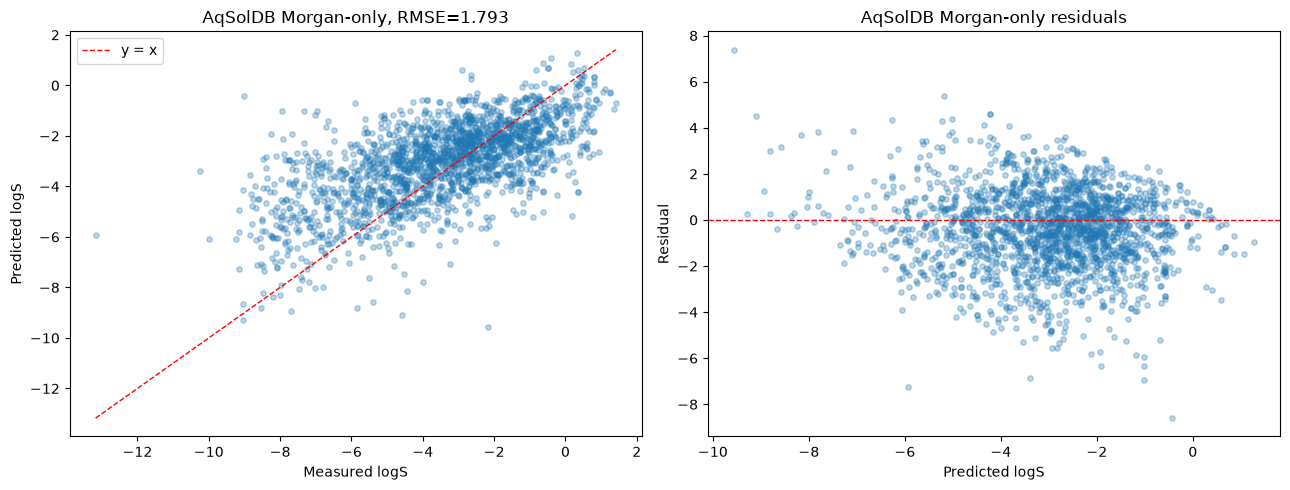

In [21]:
if res_morgan is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    axes[0].scatter(y_test, res_morgan["y_pred"], alpha=0.3, s=15)
    lo = float(min(y_test.min(), res_morgan["y_pred"].min()))
    hi = float(max(y_test.max(), res_morgan["y_pred"].max()))
    axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
    axes[0].set_xlabel("Measured logS")
    axes[0].set_ylabel("Predicted logS")
    axes[0].set_title(f"AqSolDB Morgan-only, RMSE={res_morgan['rmse']:.3f}")
    axes[0].legend()
    
    residuals_morgan = y_test.values - res_morgan["y_pred"]
    axes[1].scatter(res_morgan["y_pred"], residuals_morgan, alpha=0.3, s=15)
    axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Predicted logS")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("AqSolDB Morgan-only residuals")
    
    plt.tight_layout()
    plt.savefig("figures/aq_diagnostic_morgan.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Morgan plot skipped.")


In [22]:
if res_combined is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    axes[0].scatter(y_test, res_combined["y_pred"], alpha=0.3, s=15)
    lo = float(min(y_test.min(), res_combined["y_pred"].min()))
    hi = float(max(y_test.max(), res_combined["y_pred"].max()))
    axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1, label="y = x")
    axes[0].set_xlabel("Measured logS")
    axes[0].set_ylabel("Predicted logS")
    axes[0].set_title(f"AqSolDB Combined, RMSE={res_combined['rmse']:.3f}")
    axes[0].legend()
    
    residuals_combined = y_test.values - res_combined["y_pred"]
    axes[1].scatter(res_combined["y_pred"], residuals_combined, alpha=0.3, s=15)
    axes[1].axhline(0, color="r", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Predicted logS")
    axes[1].set_ylabel("Residual")
    axes[1].set_title("AqSolDB Combined residuals")
    
    plt.tight_layout()
    plt.savefig("figures/aq_diagnostic_combined.pdf", bbox_inches="tight")
    plt.show()
else:
    print("Combined plot skipped.")


Combined plot skipped.


## 14. Conclusions (cautious interpretation)

Fill in the specific numbers from the table above, but stick to the following
wording rules:

- Say: *"On this scaffold-aware evaluation, RDKit descriptors currently
  outperform Morgan fingerprints on AqSolDB."*
- Do not say Morgan fingerprints are bad, or that RDKit has reached a
  fundamental ceiling, or that a wider target range causes irreducible RMSE.

**Two possible reads of the gap-analysis result:**

If `gap_aqsol < gap_esol`:

> The performance gap between Morgan and RDKit narrowed substantially when
> moving from ESOL to AqSolDB. This is consistent with Morgan fingerprints
> benefiting from broader training-set coverage — each Morgan bit gets more
> training triggers, and more diverse training scaffolds shrink the
> effective distance to novel test scaffolds. RDKit descriptors improved
> less (or even worsened in raw RMSE terms) because their information
> content is bounded relative to the harder, more diverse test set.

If `gap_aqsol >= gap_esol`:

> The larger dataset did not eliminate the scaffold-generalization
> disadvantage of Morgan fingerprints under this setup. Even with 9× more
> training molecules and 5× more training scaffolds, Morgan-only test RMSE
> remained substantially worse than RDKit-only. Possible explanations
> include: AqSolDB's per-molecule label noise is higher than ESOL's; test
> scaffolds are so numerous and small that even 297 training scaffolds
> aren't enough coverage; the scaffold-generalization ceiling for Morgan on
> this task is genuinely low. Further tests (e.g., transfer learning from a
> pretrained MPNN, or a much larger dataset like ChEMBL) would be needed to
> discriminate between these.

**On NRMSE**: raw RMSE numbers across ESOL and AqSolDB are not directly
comparable because their target standard deviations differ. NRMSE is a
first-order correction — a fully rigorous cross-dataset comparison would
also account for label quality and chemistry diversity, which we cannot
easily do here.

**Deciding whether to run the RDKit + Morgan combined experiment**:
- If Morgan Test RMSE is reasonably close to RDKit Test RMSE (say within 20%),
  the combined experiment is worth running — it may reveal complementary
  signal.
- If Morgan Test RMSE is much worse (like ESOL's 2× disadvantage), combined
  is unlikely to help beyond RDKit alone, and running it is a low-value use
  of another ~2.5 hours.